In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import sys
sys.path.append('../..')

from utils.workflow import WorkflowModel
import utils.plotting as plotting
from utils.eval import eval_predictions

2026-04-02 17:01:09.195566: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-02 17:01:09.624961: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-02 17:01:10.979574: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Set the default float type to float64


E0000 00:00:1775160072.308694  532433 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775160072.315083  532433 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
df = pd.read_csv("../../data/dengue_2024-2025.csv")

In [3]:
I_data = df["I_t"].to_numpy()

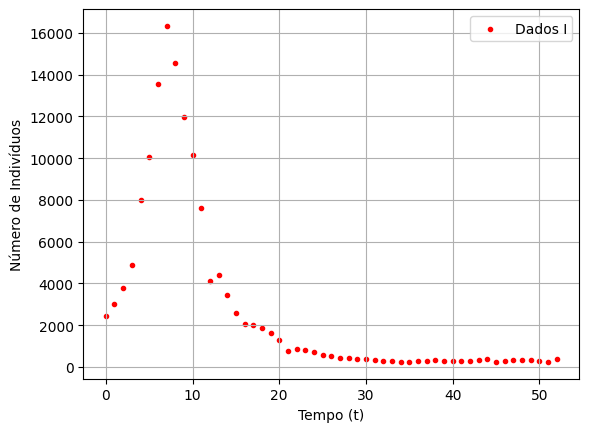

In [4]:
t_0, t_f = 0, len(I_data) - 1
data_t = np.linspace(t_0, t_f, len(I_data))
plotting.plot_prevalence_data(data_t, I_data, "Tempo (semanas)")

In [5]:
N = df["N_populacao"][0]
gamma = 1
data_t = np.linspace(t_0, t_f, len(I_data))

In [6]:
model = WorkflowModel(t_0, t_f, I_data, data_t, N, gamma, 
    scaling="min/max",
    n_hidden_layers=3,
    hidden_layer_size=20,
    w_physics=10,
    adam_iterations=500000,
    beta_estimation_method="isaac3",
    beta_estimation_window=1
)

[10, 10, 0.001, 10, 10, 10, 1]
Compiling model...
'compile' took 0.005084 s



In [7]:
model.scaled_S0, model.scaled_I0, model.scaled_N, model.beta0

(np.float64(411.46971485369943),
 np.float64(0.1353668385413431),
 np.float64(411.6050816922408),
 np.float64(1.218204517066315))

In [8]:
model.train(verbose=1)

Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
0         [3.11e-02, 2.70e-01, 6.02e-06, 1.69e+06, 1.83e-01, 1.48e+01, 1.32e-01]    [5.76e-03, 2.71e-01, 1.95e-06, 1.69e+06, 1.83e-01, 1.48e+01, 1.32e-01]    []  
100       [2.87e-01, 2.17e-01, 5.95e-06, 1.64e+06, 2.24e-02, 2.46e+00, 3.22e-02]    [3.00e-01, 2.16e-01, 6.15e-06, 1.64e+06, 2.24e-02, 2.46e+00, 3.22e-02]    []  
200       [7.47e-03, 2.37e-02, 5.23e-08, 1.61e+06, 5.03e-03, 2.43e-04, 6.62e-02]    [7.76e-03, 2.13e-02, 5.46e-08, 1.61e+06, 5.03e-03, 2.43e-04, 6.62e-02]    []  
300       [4.87e-03, 2.66e-02, 2.88e-08, 1.59e+06, 5.56e-03, 3.19e-06, 6.48e-02]    [5.08e-03, 2.42e-02, 3.00e-08, 1.59e+06, 5.56e-03, 3.19e-06, 6.48e-02]    []  
400       [6.19e-03, 2.44e-02, 2.73e-08, 1.57e+06, 3.96e-03, 7.60e-07, 6.43e-02]    [6.44e-03, 2.18e-02, 2.84e-08, 1.57e+06, 3.96e-03, 7.60e-07, 6.43e-02]    [

(<deepxde.model.LossHistory at 0x7fd18224ce10>,
 <deepxde.model.TrainState at 0x7fd1821f99d0>)

In [9]:
test_t = np.linspace(t_0, t_f, 50)
pred = model.predict(test_t)

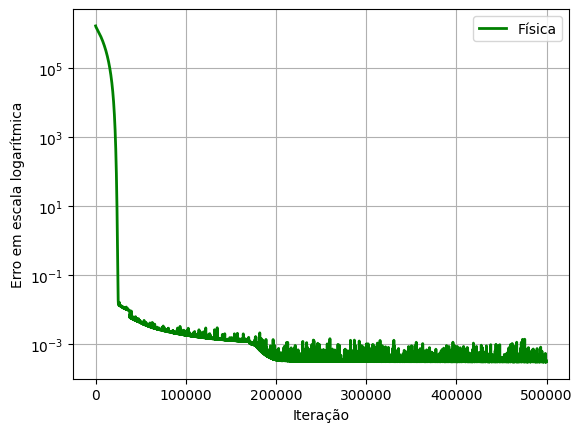

In [10]:
plotting.plot_phys_losshistory(model.losshistory, model.n_physics)

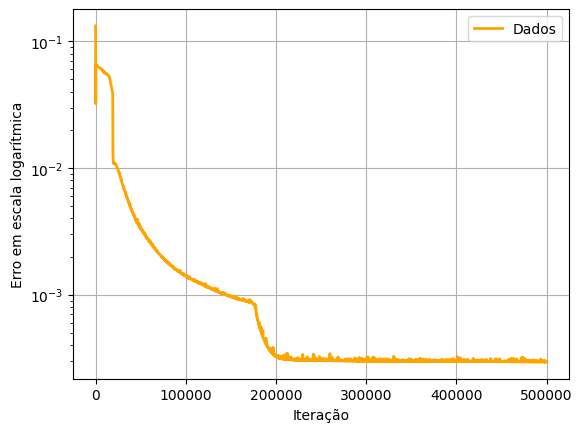

In [11]:
plotting.plot_data_losshistory(model.losshistory)

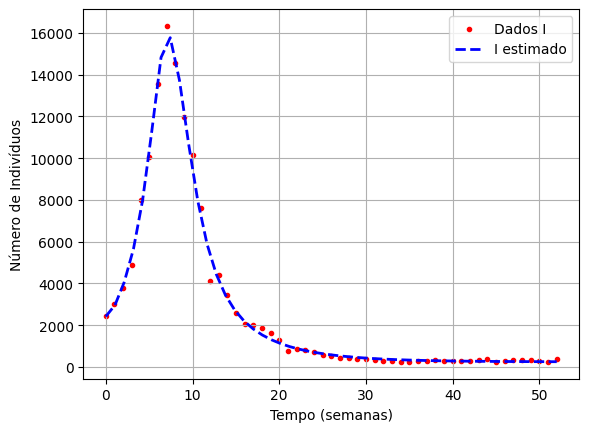

In [12]:
plotting.plot_prevalence_results(I_data, data_t, pred[:,1], test_t, xlabel="Tempo (semanas)")

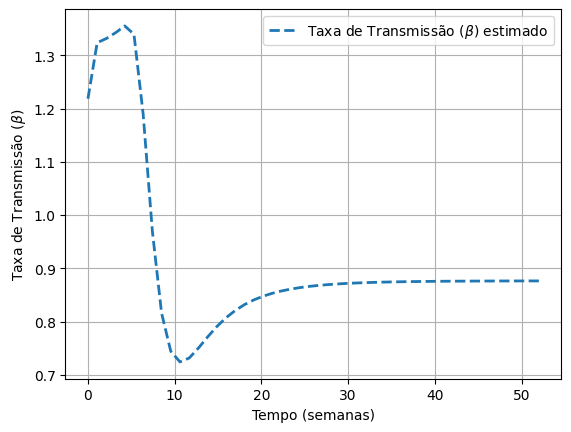

In [13]:
plotting.plot_beta_prediction(pred[:,2], test_t, xlabel="Tempo (semanas)")

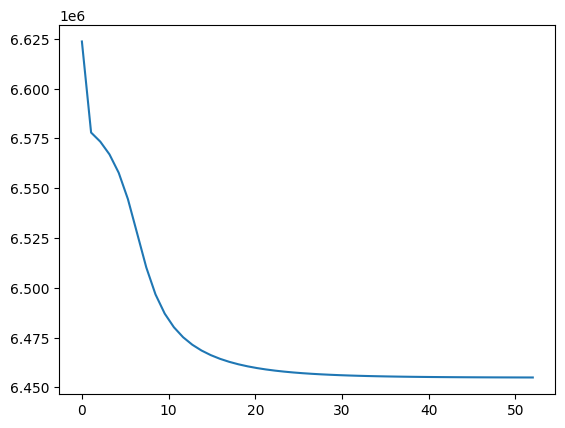

In [14]:
from matplotlib import pyplot as plt

plt.plot(test_t, pred[:,0])

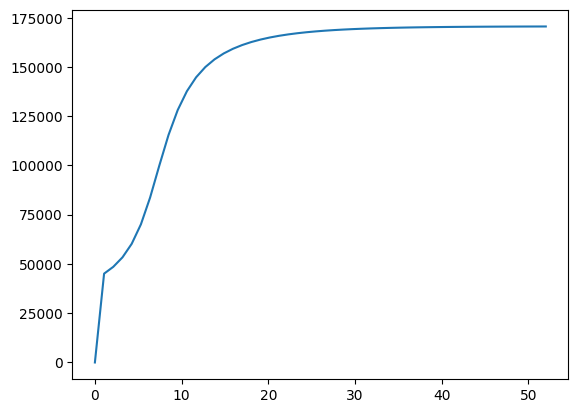

In [15]:
plt.plot(test_t, np.ones(len(test_t)) * N - pred[:,0] - pred[:,1] )